# KneeXrayData dataset audit

Run this notebook before training. It prints dataset composition, image integrity, intensity statistics, patient-side coverage, optional YOLO-manifest coverage, and representative images directly in the notebook. It writes no report and changes no dataset files.

In [1]:
!pip -q install 'h5py>=3.9' 'pandas>=2'

In [2]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import random
import cv2
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


Mounted at /content/drive


In [3]:
ROOT = Path('/content/drive/MyDrive/Datasets/KneeXrayData_Mendeley_v1')
PUBLISHED_ROOT = ROOT / 'extracted/KneeXrayData/ClsKLData/kneeKL224'
H5_ROOT = ROOT / 'extracted/KneeXrayData/DetKneeData/H5'
FULL_PNG_ROOT = ROOT / 'derived/full_bilateral_png_v2'
MANIFEST_PATH = ROOT / 'derived/production_yolo_roi_manifest_v1.csv'

if not PUBLISHED_ROOT.is_dir():
    raise FileNotFoundError(f'Published 224 dataset not found: {PUBLISHED_ROOT}')
print('Published KL images:', PUBLISHED_ROOT)
print('HDF5 source exists:', H5_ROOT.is_dir())
print('Full PNG export exists:', FULL_PNG_ROOT.is_dir())
print('YOLO manifest exists:', MANIFEST_PATH.is_file())


Published KL images: /content/drive/MyDrive/Datasets/KneeXrayData_Mendeley_v1/extracted/KneeXrayData/ClsKLData/kneeKL224
HDF5 source exists: True
Full PNG export exists: True
YOLO manifest exists: True


## Published classifier labels and image checks

In [4]:
rows, failures = [], []
for split in ('train', 'val', 'test'):
    for grade in range(5):
        for path in sorted((PUBLISHED_ROOT / split / str(grade)).glob('*.png')):
            image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
            if image is None:
                failures.append(str(path)); continue
            side, patient = path.stem[-1:].upper(), path.stem[:-1]
            rows.append({'split': split, 'grade': grade, 'patient': patient, 'side': side, 'path': str(path), 'height': image.shape[0], 'width': image.shape[1], 'mean': float(image.mean()), 'std': float(image.std()), 'min': int(image.min()), 'max': int(image.max())})
frame = pd.DataFrame(rows)
print('Decoded images:', len(frame), '| failures:', len(failures))
display(frame.groupby(['split', 'grade']).size().unstack(fill_value=0))
display(frame.groupby('split')[['height', 'width', 'mean', 'std']].agg(['min', 'mean', 'max']).round(2))
print('Unique patients per split:', frame.groupby('split').patient.nunique().to_dict())
print('Side labels:', frame.side.value_counts().to_dict())
print('Duplicate patient-side rows:', int(frame.duplicated(['split', 'patient', 'side']).sum()))
if failures: display(pd.DataFrame({'decode_failure': failures}).head(20))


Decoded images: 8260 | failures: 0


grade,0,1,2,3,4
split,,,,,
test,639,296,447,223,51
train,2286,1046,1516,757,173
val,328,153,212,106,27


height             width               mean                   std  \
         min   mean  max   min   mean  max    min    mean     max   min   
split                                                                     
test     224  224.0  224   224  224.0  224  52.11  155.14  238.21  8.86   
train    224  224.0  224   224  224.0  224  45.93  154.59  234.82  7.54   
val      224  224.0  224   224  224.0  224  41.74  156.95  239.55  9.08   

                     
        mean    max  
split                
test   38.32  84.25  
train  38.59  87.84  
val    38.65  80.93

Unique patients per split: {'test': 828, 'train': 2889, 'val': 413}
Side labels: {'L': 4130, 'R': 4130}
Duplicate patient-side rows: 0


## Grade imbalance and visual samples

Each column below is a random sample from one KL grade. The images remain the original published 224x224 classifier images.

,count,fraction
grade,,
0,3253,0.3938
1,1495,0.1810
2,2175,0.2633
3,1086,0.1315
4,251,0.0304


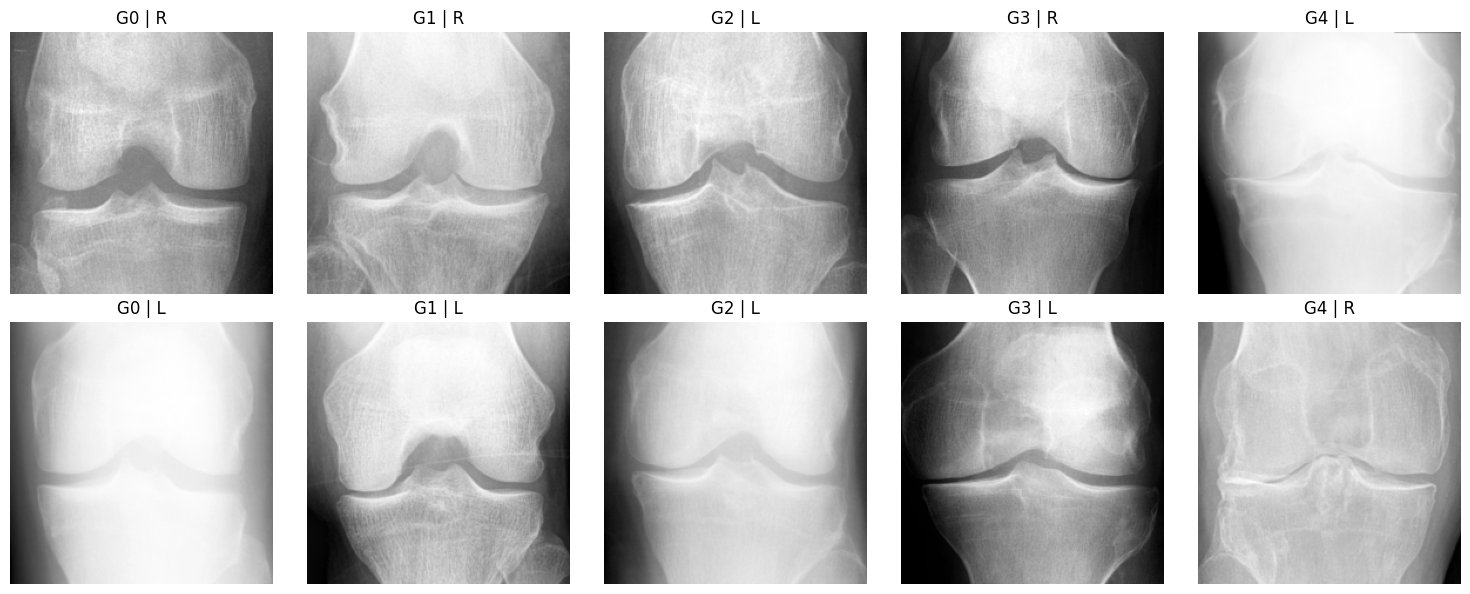

In [5]:
grade_counts = frame.grade.value_counts().sort_index()
display(pd.DataFrame({'count': grade_counts, 'fraction': (grade_counts / len(frame)).round(4)}))
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for grade in range(5):
    for row_index, row in enumerate(frame[frame.grade == grade].sample(n=2, random_state=42 + grade).itertuples()):
        image = cv2.imread(row.path, cv2.IMREAD_GRAYSCALE)
        axes[row_index, grade].imshow(image, cmap='gray'); axes[row_index, grade].set_title(f'G{grade} | {row.side}'); axes[row_index, grade].axis('off')
plt.tight_layout(); plt.show()


## Full bilateral HDF5 and YOLO ROI manifest audit

The full radiographs are HDF5 arrays. This section checks the available source files and, when the cached manifest exists, verifies that every labelled training/validation patient-side has one YOLO box.

In [6]:
if H5_ROOT.is_dir():
    h5_rows = []
    for split in ('train', 'val', 'test'):
        paths = sorted((H5_ROOT / f'{split}H5').glob('*.h5'))
        for path in paths[:min(20, len(paths))]:
            with h5py.File(path, 'r') as handle:
                image = np.asarray(handle['images'])
            h5_rows.append({'split': split, 'file': path.name, 'shape': tuple(image.shape), 'dtype': str(image.dtype), 'min': float(image.min()), 'max': float(image.max())})
        print(f'{split}: {len(paths)} HDF5 bilateral radiographs')
    display(pd.DataFrame(h5_rows).head(15))

if MANIFEST_PATH.is_file():
    manifest = pd.read_csv(MANIFEST_PATH)
    print('Manifest rows:', len(manifest))
    display(manifest.groupby(['split', 'grade']).size().unstack(fill_value=0))
    box_width = manifest.x2 - manifest.x1; box_height = manifest.y2 - manifest.y1
    display(pd.DataFrame({'box_width': box_width, 'box_height': box_height, 'square_side_at_1.15': np.ceil(np.maximum(box_width, box_height) * 1.15)}).describe().round(2))
    expected = frame[frame['split'].isin(['train', 'val'])][['split', 'patient', 'side']].drop_duplicates().copy()
    observed = manifest[['split', 'patient', 'side']].drop_duplicates().copy()
    # CSV inference turns numeric patient IDs into int64; filenames retain text.
    for key in ('split', 'patient', 'side'):
        expected[key] = expected[key].astype(str).str.strip()
        observed[key] = observed[key].astype(str).str.strip()
    missing = expected.merge(observed, on=['split', 'patient', 'side'], how='left', indicator=True)
    missing = missing[missing['_merge'] == 'left_only']
    print('Labelled train/val patient-sides missing a YOLO box:', len(missing))
    if len(missing): display(missing.head(30))
else:
    print('No manifest yet. Run the ROI preparation notebook first if you want production-ROI coverage statistics.')


train: 2889 HDF5 bilateral radiographs
val: 413 HDF5 bilateral radiographs
test: 828 HDF5 bilateral radiographs


,split,file,shape,dtype,min,max
0,train,9000099.h5,"(256, 320, 3)",float64,0.0,254.0
1,train,9000296.h5,"(256, 320, 3)",float64,4.0,176.0
2,train,9000622.h5,"(256, 320, 3)",float64,0.0,253.0
3,train,9001104.h5,"(256, 320, 3)",float64,0.0,253.0
4,train,9001695.h5,"(256, 320, 3)",float64,0.0,254.0
5,train,9001897.h5,"(256, 320, 3)",float64,2.0,254.0
6,train,9002116.h5,"(256, 320, 3)",float64,0.0,254.0
7,train,9002316.h5,"(256, 320, 3)",float64,10.0,235.0
8,train,9002411.h5,"(256, 320, 3)",float64,0.0,247.0
9,train,9002430.h5,"(256, 320, 3)",float64,1.0,236.0


Manifest rows: 6604


grade,0,1,2,3,4
split,,,,,
train,2286,1046,1516,757,173
val,328,153,212,106,27


,box_width,box_height,square_side_at_1.15
count,6604.00,6604.00,6604.00
mean,79.48,72.45,91.94
std,6.98,6.28,8.02
min,60.30,53.66,70.00
25%,74.45,67.98,86.00
50%,78.62,71.91,91.00
75%,84.56,76.82,98.00
max,105.17,92.84,121.00


ValueError: You are trying to merge on object and int64 columns for key 'patient'. If you wish to proceed you should use pd.concat

## Interpretation checklist

Check that every split contains all grades, Grade 4 is much smaller than Grade 0, images decode successfully, and the YOLO manifest has no missing patient-side rows. This notebook diagnoses data availability and geometry; it does not measure model accuracy or clinical validity.